In [ ]:
from mipt import *
import warnings
import numpy as np
import importlib
import csv
import gnme
importlib.reload(gnme)
from gnme import RingInflationSDP3Q

warnings.filterwarnings('ignore', category=UserWarning)

LEVEL = 2
STRATEGY = "feasibility"

sdp: RingInflationSDP3Q

n=8
d=2*n
ps = np.linspace(0.0, 0.5, 11)
reps = 3

if LEVEL == 2:
    sdp = RingInflationSDP3Q(domain="auto")
    with open("gnme_lvl2.csv", mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["p", "score"])
elif LEVEL == 3:
    # sdp = RingInflationSDP3QLevel3(
    #     domain="auto",          # "real", "complex", or "auto"
    #     strategy=STRATEGY  # usually more stable for SCS
    # )
    with open("gnme_lvl3.csv", mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["p", "score"])
else:
    raise ValueError("LEVEL must only be set to 2 or 3")

means, stderrs = [], []
for p in ps:
    print(f"Simulating p = {p:.2f}", end='', flush=True)
    scores = []
    for _ in range(reps):
        rhos = get_mipt_rho_1d(n, d, p, subsyst=3, all_matrices=True, closed=True)
        gmn_scores = [gmn(rho, parties=3) for rho in rhos]
        idx = max(range(len(gmn_scores)), key=gmn_scores.__getitem__)
        rho = rhos[idx]

        score: float

        if LEVEL == 2:
            score = sdp.solve(
                rho,
                gpu=False,
                verbose=False,
                max_iters=1500,
                tol=1e-8,
                time_limit_secs=45,
            )
        elif LEVEL == 3:
            score = sdp.solve(
                rho,
                strategy=STRATEGY,
                gpu=True,
                max_iters=20_000,
                tol=2e-4,
                bisect_tol=2e-3,
                verbose=True,
            )

        new_row = [p, score]

        if LEVEL == 2:
            with open("gnme_lvl2.csv", mode="a", newline="") as file:
                writer = csv.writer(file)
                writer.writerow(new_row)
        elif LEVEL == 3:
            with open("gnme_lvl3.csv", mode="a", newline="") as file:
                writer = csv.writer(file)
                writer.writerow(new_row)

        scores.append(score)
        print(".", end='', flush=True)
        
    means.append(np.mean(scores))
    stderrs.append(np.std(scores)/np.sqrt(reps))
    print(f"\nInflation Score: {means[-1]:.8g} ± {stderrs[-1]:.3g}")


plt.errorbar(ps, [1 - m for m in means], yerr=stderrs, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
plt.xlabel("p")
plt.ylabel("Adj. Inflation Score $1-s$")
plt.show()

Simulating p = 0.00...
Inflation Score: 1 ± 2.11e-12
Simulating p = 0.05...
Inflation Score: 1 ± 3.69e-09
Simulating p = 0.10...
Inflation Score: 1 ± 0
Simulating p = 0.15...
Inflation Score: 0.96891366 ± 0.0254
Simulating p = 0.20.

In [ ]:
import numpy as np
from level3_ring_scs_orbit_fast import solve_level3_ring_inflation_scs
from mipt import get_mipt_rho_1d, gmn

n = 8
d = 2*n
p = 0.17

rhos = get_mipt_rho_1d(n, d, p, subsyst=3, all_matrices=True, closed=True)
gmn_scores = [gmn(rho, parties=3) for rho in rhos]
print(gmn_scores)

idx = max(range(len(gmn_scores)), key=gmn_scores.__getitem__)

result = solve_level3_ring_inflation_scs(
    rhos[idx],
    complex_problem=None,      # auto-detects complex rho
    bisect_tol=5e-3,
    max_bisect_steps=8,
    verbose_build=True,
    verbose_scs=True,
    max_iters=1000,
    eps_abs=2e-4,
    eps_rel=2e-4,
    normalize=True,
    acceleration_lookback=0,
)

print(result)

[0.0, 0.027561166812319453, 0.006063597082175623, 0.0, 0.0, 0.0, 0.0, 0.0]
Building orbit-reduced/direct-map SCS structure, complex=True, vars=266,304 [gamma=87,424, tau=133,120, sigma=45,760]
  orbit counts: gamma(real=43,800, imag=43,624), tau(real=66,816, imag=66,304), sigma(real=23,052, imag=22,708)
  equality sigma_012 = target: rows=64, nnz=2,304
  equality Tr(sigma)=1: rows=1, nnz=120
  equality Tr(tau)=1: rows=1, nnz=288
  equality Tr(gamma)=1: rows=1, nnz=176
  equality gamma_7801245 = tau_4501278: rows=16,384, nnz=130,944
  equality tau_1245678 = sigma_1245678: rows=16,384, nnz=128,352
  equality gamma_0123467 = tau_0123467: rows=16,384, nnz=130,944
  equality tau_0134678 = sigma_0134678: rows=16,384, nnz=128,352
  equality gamma_8012356 = tau_5012386: rows=16,384, nnz=130,944
  equality tau_2350678 = sigma_2053678: rows=16,384, nnz=128,352
  PSD sigma >= 0: dim=512, rows=262,144, nnz=261,472
  PSD tau >= 0: dim=512, rows=262,144, nnz=261,920
  PSD gamma >= 0: dim=512, rows=2

In [5]:
from mipt import get_mipt_rho_1d, gmn

n = 8
d = 2*n
p = 0.17

rhos = get_mipt_rho_1d(n, d, p, subsyst=3, all_matrices=True, closed=True)
gmn_scores = [gmn(rho, parties=3) for rho in rhos]
print(gmn_scores)
idx = max(range(len(gmn_scores)), key=gmn_scores.__getitem__)
print(idx)

[0.0, 0.0, 0.01057244346457541, 0.0, 0.0, 0.0, 0.031283861851436404, 0.0]
6


In [ ]:
from numpy.typing import NDArray
ComplexVector = NDArray[np.complex128]
ComplexMatrix = NDArray[np.complex128]
from gnme import inflation_score
import numpy as np
from read_mipt_rho3 import read_rho3_bin
from collections import defaultdict

def scan_func_by_p(records, func, limit=None):
    """
    Compute mean ± sample stddev of a given function at each p.

    Parameters
    ----------
    records : list[dict]
        Output from read_rho3_bin(...).

    func : callable
        Function taking one 8x8 density matrix and returning a scalar.

    limit : int | None
        Maximum number of matrices to evaluate for each p.
        If None, all matrices are used.

    Returns
    -------
    results : dict[float, dict]
    """

    if limit is not None:
        if not isinstance(limit, int):
            raise TypeError("limit must be an int or None.")
        if limit <= 0:
            raise ValueError("limit must be positive when provided.")

    grouped = defaultdict(list)

    for rec in records:
        grouped[float(rec["p"])].append(rec)

    results = {}

    for p in sorted(grouped):
        group = grouped[p]

        if limit is not None:
            group = group[:limit]

        values = np.asarray(
            [
                float(np.real_if_close(func(rec["rho"])))
                for rec in group
            ],
            dtype=float,
        )

        results[p] = {
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
            "n": int(len(values)),
            "values": values,
        }

    return results

def mixed_ghz_3q(p):
    # Define the basis states
    ket0 = np.array([1, 0])
    ket1 = np.array([0, 1])

    # |000> state = |0> ⊗ |0> ⊗ |0>
    ket000 = np.kron(np.kron(ket0, ket0), ket0)

    # |111> state = |1> ⊗ |1> ⊗ |1>
    ket111 = np.kron(np.kron(ket1, ket1), ket1)

    # 1/sqrt(2) * (|000> + |111>)
    ghz_state = (1 / np.sqrt(2)) * (ket000 + ket111)

    # Density matrix representation: rho = |GHZ><GHZ|
    return (1-p)*np.outer(ghz_state, ghz_state) + p * np.eye(8) / 8


# records = read_rho3_bin("rho3.bin")

# results = scan_func_by_p(records, inflation_score, limit=10)

# for p, stats in results.items():
#     print(
#         f"p={p:.3f}: "
#         f"F_GHZ = {stats['mean']:.6f} ± {stats['std']:.6f} "
#         f"(n={stats['n']})"
#     )

# p_vals = np.array(sorted(results.keys()))
# means = np.array([results[p]["mean"] for p in p_vals])
# stds = np.array([results[p]["std"] for p in p_vals])
# ns = np.array([results[p]["n"] for p in p_vals])

def ket0():
    return np.array([1, 0], dtype=np.complex128)


def ket1():
    return np.array([0, 1], dtype=np.complex128)


def dm(psi):
    psi = np.asarray(psi, dtype=np.complex128)
    return np.outer(psi, psi.conj())


def normalize(psi):
    psi = np.asarray(psi, dtype=np.complex128)
    return psi / np.linalg.norm(psi)


def kron_all(*ops):
    out = np.array([[1]], dtype=np.complex128)
    for op in ops:
        out = np.kron(out, op)
    return out


def pure_product_abc(a, b, c):
    psi = np.kron(np.kron(a, b), c)
    return dm(psi)


def bell_phi_plus():
    return normalize(np.array([1, 0, 0, 1], dtype=np.complex128))


def ghz3():
    psi = np.zeros(8, dtype=np.complex128)
    psi[0] = 1 / np.sqrt(2)
    psi[7] = 1 / np.sqrt(2)
    return dm(psi)


def w3():
    psi = np.zeros(8, dtype=np.complex128)
    psi[1] = 1 / np.sqrt(3)  # |001>
    psi[2] = 1 / np.sqrt(3)  # |010>
    psi[4] = 1 / np.sqrt(3)  # |100>
    return dm(psi)


def white_mix(rho, p):
    """
    rho_p = (1-p) rho + p I/d
    where p is the white-noise fraction.
    """
    d = rho.shape[0]
    return (1 - p) * rho + p * np.eye(d, dtype=np.complex128) / d


def bell_ab_product_c():
    """
    |Phi+>_AB tensor |0>_C
    in output order A,B,C.
    """
    bell = bell_phi_plus()  # order A,B
    c = ket0()

    psi = np.kron(bell, c)  # AB,C -> A,B,C
    return dm(psi)


def bell_ac_product_b():
    """
    |Phi+>_AC tensor |0>_B
    output order A,B,C.
    """
    psi = np.zeros(8, dtype=np.complex128)

    # (|00>_AC + |11>_AC)/sqrt(2) tensor |0>_B
    # output order A,B,C:
    # A=0,B=0,C=0 -> |000>
    # A=1,B=0,C=1 -> |101>
    psi[0b000] = 1 / np.sqrt(2)
    psi[0b101] = 1 / np.sqrt(2)

    return dm(psi)


def bell_bc_product_a():
    """
    |0>_A tensor |Phi+>_BC
    output order A,B,C.
    """
    a = ket0()
    bell = bell_phi_plus()  # order B,C

    psi = np.kron(a, bell)  # A,BC -> A,B,C
    return dm(psi)

rho_000 = pure_product_abc(ket0(), ket0(), ket0())
rho_111 = pure_product_abc(ket1(), ket1(), ket1())

print("product |000>:", inflation_score(rho_000, verbose=False))
print("product |111>:", inflation_score(rho_111, verbose=False))

tests = {
    "Bell_AB x |0>_C": bell_ab_product_c(),
    "Bell_AC x |0>_B": bell_ac_product_b(),
    "Bell_BC x |0>_A": bell_bc_product_a(),
}

for name, rho in tests.items():
    val = inflation_score(rho, verbose=False)
    print(f"{name:20s}  t_max = {val:.8f}")

rho_bisep_mix = (
    0.25 * bell_ab_product_c()
    + 0.35 * bell_ac_product_b()
    + 0.40 * bell_bc_product_a()
)

print("mixed biseparable network:", inflation_score(rho_bisep_mix, verbose=False))

product |000>: 0.9999999891136315
product |111>: 0.9999999891136175
Bell_AB x |0>_C       t_max = 0.99999205
Bell_AC x |0>_B       t_max = 0.99999205
Bell_BC x |0>_A       t_max = 0.99999207
mixed biseparable network: 1


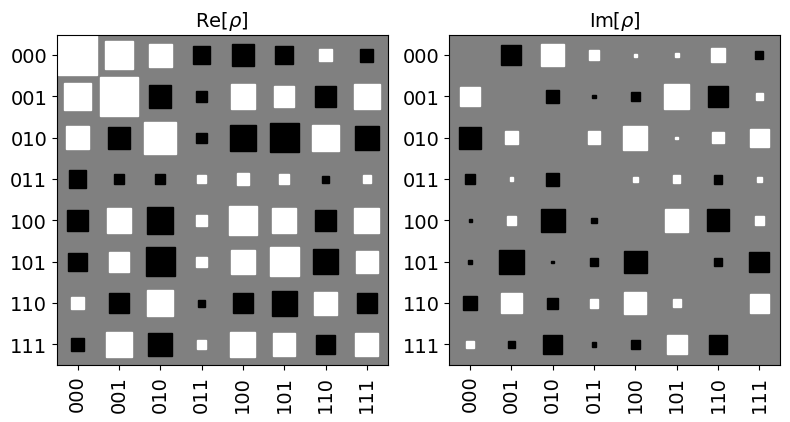

In [40]:
import numpy as np
from qiskit.quantum_info import partial_trace, DensityMatrix
from mipt import *

def dm(psi):
    psi = np.asarray(psi, dtype=np.complex128)
    return np.outer(psi, psi.conj())


def ghz3():
    psi = np.zeros(8, dtype=np.complex128)
    psi[0] = 1 / np.sqrt(2)
    psi[7] = 1 / np.sqrt(2)
    return dm(psi)


def ghz4():
    psi = np.zeros(16, dtype=np.complex128)
    psi[0] = 1 / np.sqrt(2)
    psi[15] = 1 / np.sqrt(2)
    return dm(psi)

n = 4
d = 2*n
p = 0.0

rho = get_mipt_rho_1d(n, d, p, subsyst=3, closed=True)

rho.draw("hinton")


In [11]:
def haar_unitary(dim, rng):
    z = rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))
    q, r = np.linalg.qr(z)

    diag = np.diag(r)
    phases = np.ones(dim, dtype=np.complex128)
    nz = np.abs(diag) > 0
    phases[nz] = diag[nz] / np.abs(diag[nz])

    return q * phases.conj()


def apply_unitary_to_subsystems_statevec(psi, U, targets, dims):
    """
    Apply U to selected subsystems of a pure state vector.

    dims:
        subsystem dimensions.

    targets:
        subsystem indices acted on by U, in the order U expects.
    """
    dims = list(dims)
    n = len(dims)
    targets = list(targets)

    psi_t = psi.reshape(dims)

    perm = targets + [i for i in range(n) if i not in targets]
    inv_perm = np.argsort(perm)

    front_dim = int(np.prod([dims[i] for i in targets]))
    back_dim = int(np.prod([dims[i] for i in range(n) if i not in targets]))

    psi_perm = np.transpose(psi_t, perm).reshape(front_dim, back_dim)
    psi_perm = U @ psi_perm

    psi_out = psi_perm.reshape([dims[i] for i in perm])
    psi_out = np.transpose(psi_out, inv_perm)

    return psi_out.reshape(-1)


def partial_trace_numeric(rho, dims, keep):
    """
    Numeric ordered marginal, keeping subsystems in the listed order.
    """
    dims = list(dims)
    keep = list(keep)
    n = len(dims)

    trace = [i for i in range(n) if i not in keep]

    T = rho.reshape(*dims, *dims)
    current_dims = list(dims)

    for s in sorted(trace, reverse=True):
        T = np.trace(T, axis1=s, axis2=s + len(current_dims))
        current_dims.pop(s)

    remaining = [i for i in range(n) if i in keep]

    perm_ket = [remaining.index(i) for i in keep]
    k = len(keep)
    perm = perm_ket + [p + k for p in perm_ket]

    T = np.transpose(T, perm)

    d_keep = int(np.prod([dims[i] for i in keep]))
    return T.reshape(d_keep, d_keep)


def triangle_bell_network_state(seed=0, keep_local=(0, 0, 0)):
    """
    Build a 3-qubit state known to be in the triangle network set.

    Virtual subsystem order:
        [A0, A1, B0, B1, C0, C1]

    Link Bell pairs:
        A0-B0
        B1-C0
        C1-A1

    Local nodes:
        A = [A0, A1] = [0, 1]
        B = [B0, B1] = [2, 3]
        C = [C0, C1] = [4, 5]

    keep_local:
        Which local qubit to keep at each node after the local unitary.
        For example (0,0,0) keeps A0, B0, C0.
    """
    rng = np.random.default_rng(seed)

    dims = [2, 2, 2, 2, 2, 2]
    d = 64

    # Build the 6-qubit state:
    # Bell(A0,B0) Bell(B1,C0) Bell(C1,A1)
    #
    # We fill amplitudes explicitly in virtual order [A0,A1,B0,B1,C0,C1].
    psi = np.zeros(d, dtype=np.complex128)

    for x in [0, 1]:  # A0 = B0
        for y in [0, 1]:  # B1 = C0
            for z in [0, 1]:  # C1 = A1
                A0 = x
                B0 = x

                B1 = y
                C0 = y

                C1 = z
                A1 = z

                bits = [A0, A1, B0, B1, C0, C1]
                idx = 0
                for bit in bits:
                    idx = 2 * idx + bit

                psi[idx] = 1 / np.sqrt(8)

    # Random local unitaries at nodes.
    UA = haar_unitary(4, rng)
    UB = haar_unitary(4, rng)
    UC = haar_unitary(4, rng)

    psi = apply_unitary_to_subsystems_statevec(psi, UA, [0, 1], dims)
    psi = apply_unitary_to_subsystems_statevec(psi, UB, [2, 3], dims)
    psi = apply_unitary_to_subsystems_statevec(psi, UC, [4, 5], dims)

    rho6 = dm(psi)

    # Choose one output qubit from each node.
    A_keep = [0, 1][keep_local[0]]
    B_keep = [2, 3][keep_local[1]]
    C_keep = [4, 5][keep_local[2]]

    rho_abc = partial_trace_numeric(rho6, dims, [A_keep, B_keep, C_keep])

    # Symmetrize tiny numerical noise.
    rho_abc = (rho_abc + rho_abc.conj().T) / 2
    rho_abc = rho_abc / np.trace(rho_abc)

    return rho_abc

for seed in range(5):
    rho_net = triangle_bell_network_state(seed=seed, keep_local=(0, 0, 0))
    val = inflation_score(rho_net, verbose=False)
    print(f"triangle Bell network seed={seed}: t_max = {val:.8f}")

triangle Bell network seed=0: t_max = 1.00000000
triangle Bell network seed=1: t_max = 1.00000000
triangle Bell network seed=2: t_max = 0.99999900
triangle Bell network seed=3: t_max = 0.99999540
triangle Bell network seed=4: t_max = 0.99999994


In [3]:
import time
import scs
from gnme import RingInflationSDP3Q
from mipt import *

n=4
d=2*n

rho = get_mipt_rho_1d(n, d, p=0.3, subsyst=3, closed=True)

def test_backend(label, solve_kwargs):
    sdp = RingInflationSDP3Q()
    t0 = time.perf_counter()

    try:
        out = sdp.solve(
            rho,
            verbose=True,
            return_info=True,
            max_iters=200, 
            tol=1e-3,
            **solve_kwargs,
        )
        dt = time.perf_counter() - t0
        print("\n", label)
        print("elapsed:", dt)
        print("out:", out)
    except Exception as e:
        dt = time.perf_counter() - t0
        print("\n", label, "FAILED after", dt)
        print(type(e).__name__, e)

test_backend("CPU default", dict(gpu=False))

test_backend("CPU indirect", dict(
    gpu=False,
    use_indirect=True,
))

test_backend("cuDSS", dict(
    gpu=True,
))

(CVXPY) Jun 08 02:40:10 PM: Your problem has 8193 variables, 17664 constraints, and 64 parameters.
(CVXPY) Jun 08 02:40:10 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jun 08 02:40:10 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jun 08 02:40:10 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jun 08 02:40:10 PM: Compiling problem (target solver=SCS).
(CVXPY) Jun 08 02:40:10 PM: Reduction chain: EvalParams -> Complex2Real -> FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Jun 08 02:40:10 PM: Applying reduction EvalParams
(CVXPY) Jun 08 02:40:10 PM: Applying reduction Complex2Real


                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Jun 08 02:40:11 PM: Applying reduction FlipObjective
(CVXPY) Jun 08 02:40:11 PM: Applying reduction Dcp2Cone
(CVXPY) Jun 08 02:40:11 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jun 08 02:40:11 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Jun 08 02:40:17 PM: Applying reduction SCS
(CVXPY) Jun 08 02:40:17 PM: Finished problem compilation (took 6.344e+00 seconds).
(CVXPY) Jun 08 02:40:17 PM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 8193, constraints m: 35380
cones: 	  z: primal zero / dual free vars: 9026
	  l: linear vars: 2
	  s: psd vars: 26352, ssize: 6
settings: eps_abs: 1.0e-03, eps_rel: 1.0e-03, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 200, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 53530, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res | 

(CVXPY) Jun 08 02:40:48 PM: Problem status: optimal
(CVXPY) Jun 08 02:40:49 PM: Optimal value: 9.998e-01
(CVXPY) Jun 08 02:40:49 PM: Compilation took 6.344e+00 seconds
(CVXPY) Jun 08 02:40:49 PM: Solver (including time spent in interface) took 3.173e+01 seconds
(CVXPY) Jun 08 02:40:49 PM: Your problem has 8193 variables, 17664 constraints, and 64 parameters.
(CVXPY) Jun 08 02:40:49 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jun 08 02:40:49 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jun 08 02:40:49 PM: Your problem is compiled with the CPP canonicalization backend.


...

   100| 1.52e-03  5.05e-04  2.45e-04 -1.00e+00  1.00e-01  6.76e+01 
------------------------------------------------------------------
status:  solved
timings: total: 6.76e+01s = setup: 4.33e-02s + solve: 6.76e+01s
	 lin-sys: 3.89e+00s, cones: 6.25e+01s, accel: 1.07e+00s
------------------------------------------------------------------
objective = -1.000103
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------

 CPU indirect
elapsed: 68.64338818498072
out: InflationResult(score=1.0, raw_score=1.0002253933761107, status='optimal', solve_time=67.591192526, setup_time=0.043323187, num_iters=100)
                                     CVXPY                                     
                                     v1.7.5                       

(CVXPY) Jun 08 02:41:57 PM: Applying reduction FlipObjective
(CVXPY) Jun 08 02:41:57 PM: Applying reduction Dcp2Cone
(CVXPY) Jun 08 02:41:57 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jun 08 02:41:57 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Jun 08 02:41:58 PM: Applying reduction SCS
(CVXPY) Jun 08 02:41:58 PM: Finished problem compilation (took 6.835e-01 seconds).
(CVXPY) Jun 08 02:41:58 PM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 8193, constraints m: 35380
cones: 	  z: primal zero / dual free vars: 9026
	  l: linear vars: 2
	  s: psd vars: 26352, ssize: 6
settings: eps_abs: 1.0e-03, eps_rel: 1.0e-03, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 200, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-cuDSS
	  nnz(A): 53530, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res |   ga

(CVXPY) Jun 08 02:42:47 PM: Problem status: optimal
(CVXPY) Jun 08 02:42:47 PM: Optimal value: 9.998e-01
(CVXPY) Jun 08 02:42:47 PM: Compilation took 6.835e-01 seconds
(CVXPY) Jun 08 02:42:47 PM: Solver (including time spent in interface) took 4.921e+01 seconds


    75| 2.08e-04  4.79e-05  3.08e-04 -1.00e+00  1.00e-01  4.91e+01 
------------------------------------------------------------------
status:  solved
timings: total: 4.91e+01s = setup: 2.41e+00s + solve: 4.67e+01s
	 lin-sys: 2.66e+00s, cones: 4.20e+01s, accel: 1.89e+00s
------------------------------------------------------------------
objective = -0.999946
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------

 cuDSS
elapsed: 49.9440099800122
out: InflationResult(score=0.9997917941920629, raw_score=0.9997917941920629, status='optimal', solve_time=46.727706319, setup_time=2.4115203970000003, num_iters=75)
